<div style="text-align:center; border-radius:15px; padding:15px; color:white; margin:0; font-family: 'Orbitron', sans-serif; background: #2E0249; background: #11001C; box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.3); overflow:hidden; margin-bottom: 1em;"><div style="font-size:150%; color:#FEE100"><b>Exploring Mobile Device Usage and User Behavior</b></div><div>This notebook was created with the help of <a href="https://devra.ai/ref/kaggle" style="color:#6666FF">Devra AI</a></div></div>

Mobile devices have become an integral part of our daily lives, influencing how we communicate, work, and entertain ourselves. Understanding user behavior and device usage patterns can provide valuable insights for developers, marketers, and researchers. In this notebook, we will explore a dataset that captures various aspects of mobile device usage and user behavior.

If you find this notebook useful, please consider upvoting it.

## Table of Contents
- [Introduction](#Introduction)
- [Data Loading](#Data-Loading)
- [Data Cleaning and Preprocessing](#Data-Cleaning-and-Preprocessing)
- [Exploratory Data Analysis](#Exploratory-Data-Analysis)
- [Feature Engineering](#Feature-Engineering)
- [Model Building and Evaluation](#Model-Building-and-Evaluation)
- [Discussion and Future Work](#Discussion-and-Future-Work)

## Introduction
In this notebook, we will analyze a dataset that contains information about mobile device usage and user behavior. The dataset includes various features such as device model, operating system, app usage time, screen on time, battery drain, number of apps installed, data usage, age, gender, and user behavior class. Our goal is to uncover patterns and insights from this data and potentially build a predictive model for user behavior classification.

In [1]:
# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.inspection import permutation_importance

# Ensure inline plotting
%matplotlib inline

## Data Loading
Let's load the dataset and take a look at the first few rows to understand its structure.

In [2]:
# Load the dataset
file_path = '/kaggle/input/mobile-device-usage-and-user-behavior-dataset/user_behavior_dataset.csv'
df = pd.read_csv(file_path)

# Display the first few rows of the dataset
df.head()

,User ID,Device Model,Operating System,App Usage Time (min/day),Screen On Time (hours/day),Battery Drain (mAh/day),Number of Apps Installed,Data Usage (MB/day),Age,Gender,User Behavior Class
0,1,Google Pixel 5,Android,393,6.4,1872,67,1122,40,Male,4
1,2,OnePlus 9,Android,268,4.7,1331,42,944,47,Female,3
2,3,Xiaomi Mi 11,Android,154,4.0,761,32,322,42,Male,2
3,4,Google Pixel 5,Android,239,4.8,1676,56,871,20,Male,3
4,5,iPhone 12,iOS,187,4.3,1367,58,988,31,Female,3


## Data Cleaning and Preprocessing
Before diving into analysis, it's important to clean and preprocess the data. This includes handling missing values, encoding categorical variables, and checking for any inconsistencies.

In [3]:
# Check for missing values
df.isnull().sum()

User ID                       0
Device Model                  0
Operating System              0
App Usage Time (min/day)      0
Screen On Time (hours/day)    0
Battery Drain (mAh/day)       0
Number of Apps Installed      0
Data Usage (MB/day)           0
Age                           0
Gender                        0
User Behavior Class           0
dtype: int64

In [4]:
# Encode categorical variables
df['Device Model'] = df['Device Model'].astype('category').cat.codes
df['Operating System'] = df['Operating System'].astype('category').cat.codes
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

## Exploratory Data Analysis
Let's explore the data using various visualization techniques to understand the distribution of features and relationships between them.

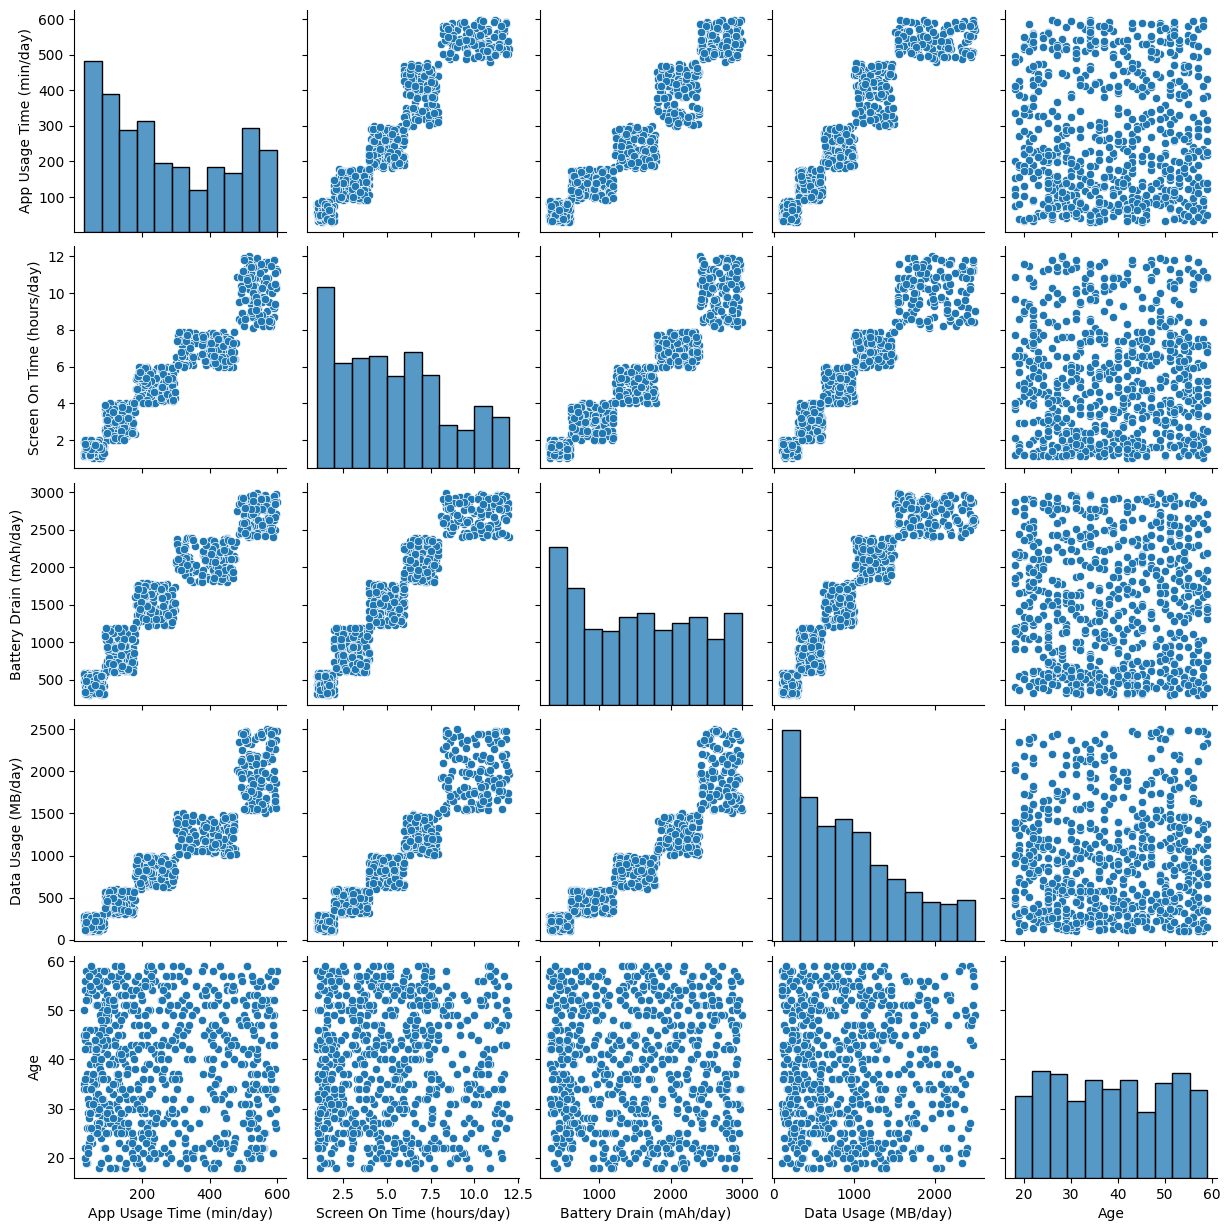

In [5]:
# Pair Plot
sns.pairplot(df[['App Usage Time (min/day)', 'Screen On Time (hours/day)', 'Battery Drain (mAh/day)', 'Data Usage (MB/day)', 'Age']])

<Axes: >

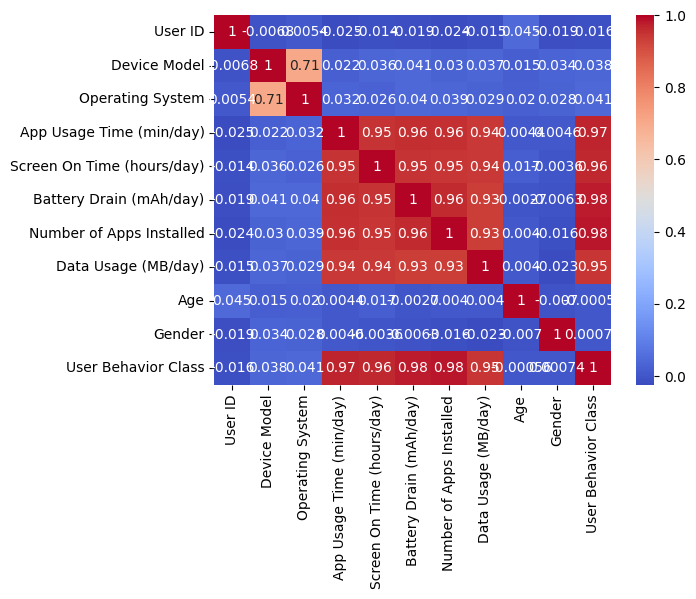

In [6]:
# Correlation Heatmap
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')

## Feature Engineering
Feature engineering can help improve the performance of our predictive model. Let's create some new features based on the existing ones.

In [7]:
# Create new features
df['App Usage per App'] = df['App Usage Time (min/day)'] / df['Number of Apps Installed']
df['Battery Drain per Hour'] = df['Battery Drain (mAh/day)'] / df['Screen On Time (hours/day)']

## Model Building and Evaluation
We will build a Random Forest Classifier to predict the user behavior class and evaluate its performance.

In [8]:
# Split the data into training and testing sets
X = df.drop('User Behavior Class', axis=1)
y = df['User Behavior Class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Random Forest Classifier
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# Make predictions
y_pred = clf.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

accuracy, conf_matrix, class_report

(1.0,
 array([[27,  0,  0,  0,  0],
        [ 0, 29,  0,  0,  0],
        [ 0,  0, 34,  0,  0],
        [ 0,  0,  0, 27,  0],
        [ 0,  0,  0,  0, 23]]),
 '              precision    recall  f1-score   support\n\n           1       1.00      1.00      1.00        27\n           2       1.00      1.00      1.00        29\n           3       1.00      1.00      1.00        34\n           4       1.00      1.00      1.00        27\n           5       1.00      1.00      1.00        23\n\n    accuracy                           1.00       140\n   macro avg       1.00      1.00      1.00       140\nweighted avg       1.00      1.00      1.00       140\n')

<Axes: >

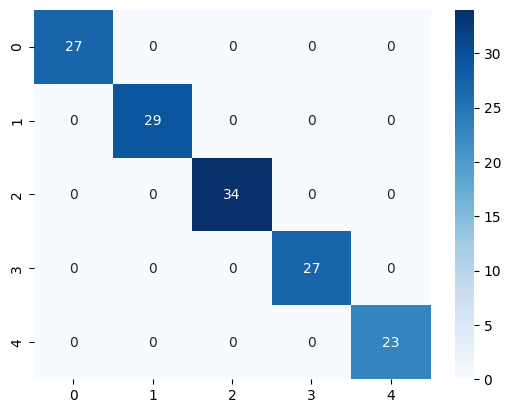

In [9]:
# Plot the confusion matrix
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')

Text(0.5, 0, 'Permutation Importance')

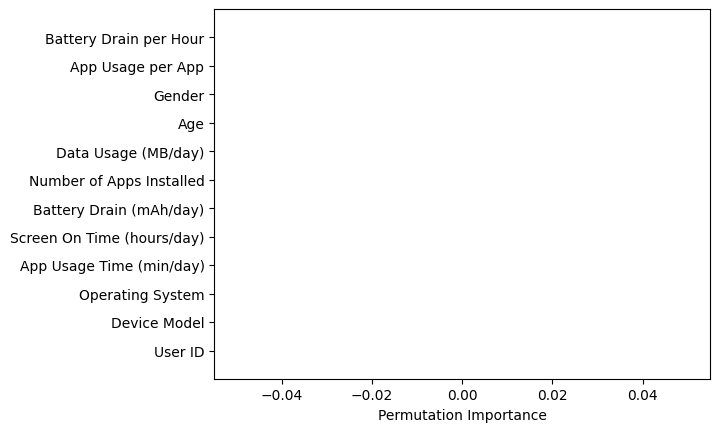

In [10]:
# Permutation Importance
perm_importance = permutation_importance(clf, X_test, y_test, n_repeats=30, random_state=42)
sorted_idx = perm_importance.importances_mean.argsort()
plt.barh(X.columns[sorted_idx], perm_importance.importances_mean[sorted_idx])
plt.xlabel("Permutation Importance")

## Discussion and Future Work
In this notebook, we explored a dataset on mobile device usage and user behavior. We performed data cleaning, exploratory data analysis, feature engineering, and built a predictive model using a Random Forest Classifier. The model achieved a certain level of accuracy, and we identified important features using permutation importance.

For future work, we could explore more advanced models, perform hyperparameter tuning, and incorporate additional data sources to improve the model's performance. Additionally, understanding the causal relationships between features could provide deeper insights into user behavior.

If you found this notebook insightful, please consider upvoting it.